# NB5: 回测引擎

## 目的
> NB2-NB4中每个Notebook各自内嵌了简易回测逻辑。本Notebook将其抽离为一个统一、可复用的回测框架，支持分仓、手续费、滑点模拟，并输出标准化的绩效报告。

## 决策日志
| 决策 | 选择 | 为什么 |
|------|------|--------|
| 回测方式 | 逐K线模拟 | 最接近真实交易，避免用未来数据 |
| 手续费 | 0.1% | Binance现货taker费率 |
| 滑点模型 | 固定0.05% | 简化模型，BTC/USDT流动性好，实际滑点很小 |
| 初始资金 | 100,000 USDT | 方便计算绝对收益 |

---
## 1. 加载数据

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import json
import warnings

warnings.filterwarnings('ignore')
matplotlib.rcParams['font.sans-serif'] = ['Microsoft YaHei']
matplotlib.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-whitegrid')

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_parquet('../data/btc_usdt_1h_clean.parquet')
with open('../data/config.json', 'r') as f:
    CONFIG = json.load(f)

print(f"已加载: {len(df):,} 条 {CONFIG['symbol']} {CONFIG['timeframe']} K线")

已加载: 35,064 条 BTC/USDT 1h K线


---
## 2. 回测引擎

支持功能：分仓交易、手续费、滑点模拟、资金曲线、逐笔交易记录。

In [2]:
class BacktestEngine:
    """统一回测引擎"""
    
    def __init__(self, initial_capital=100000, fee=0.001, slippage=0.0005):
        self.initial_capital = initial_capital
        self.fee = fee
        self.slippage = slippage
    
    def run(self, df, signal_col='signal'):
        """
        执行回测
        - df: 必须包含 close, returns 和 signal_col 列
        - signal_col: 仓位信号列，0~1之间
        """
        data = df.copy()
        
        capital = self.initial_capital
        position = 0.0  # 当前仓位比例
        
        equity_curve = []
        trades = []
        
        for i in range(len(data)):
            close = data['close'].iloc[i]
            target_position = data[signal_col].iloc[i]
            ret = data['returns'].iloc[i] if i > 0 else 0
            
            # 先更新持仓收益
            capital *= (1 + position * ret)
            
            # 仓位变化时产生交易成本
            if target_position != position:
                change = abs(target_position - position)
                cost = capital * change * (self.fee + self.slippage)
                capital -= cost
                
                if change > 0.01:  # 记录有意义的交易
                    trades.append({
                        'time': data.index[i],
                        'action': '加仓' if target_position > position else '减仓',
                        'from': f"{position:.0%}",
                        'to': f"{target_position:.0%}",
                        'capital': capital,
                        'price': close,
                    })
                
                position = target_position
            
            equity_curve.append({
                'time': data.index[i],
                'capital': capital,
                'position': position,
            })
        
        # 构建结果
        equity_df = pd.DataFrame(equity_curve).set_index('time')
        equity_df['returns'] = equity_df['capital'].pct_change()
        equity_df['cumulative'] = equity_df['capital'] / self.initial_capital
        
        # 买入持有基准
        equity_df['buy_hold'] = data['close'] / data['close'].iloc[0]
        
        trades_df = pd.DataFrame(trades) if trades else pd.DataFrame()
        
        return equity_df, trades_df
    
    def report(self, equity_df, trades_df, name='策略'):
        """生成绩效报告"""
        ret = equity_df['returns'].dropna()
        cum = equity_df['cumulative']
        
        total_return = cum.iloc[-1] - 1
        n_hours = len(ret)
        annual_return = (1 + total_return) ** (8760 / n_hours) - 1
        annual_vol = ret.std() * np.sqrt(8760)
        sharpe = annual_return / annual_vol if annual_vol != 0 else 0
        
        peak = cum.cummax()
        drawdown = (cum - peak) / peak
        max_dd = drawdown.min()
        max_dd_date = drawdown.idxmin()
        
        # 回撤恢复时间
        dd_end = drawdown.loc[max_dd_date:]
        recovery = dd_end[dd_end >= 0]
        recovery_days = (recovery.index[0] - max_dd_date).days if len(recovery) > 0 else '未恢复'
        
        win_rate = (ret > 0).sum() / (ret != 0).sum() if (ret != 0).sum() > 0 else 0
        
        return {
            '策略': name,
            '初始资金': f"${self.initial_capital:,.0f}",
            '最终资金': f"${equity_df['capital'].iloc[-1]:,.0f}",
            '总收益': f"{total_return:.1%}",
            '年化收益': f"{annual_return:.1%}",
            '年化波动': f"{annual_vol:.1%}",
            '夏普比率': f"{sharpe:.2f}",
            '最大回撤': f"{max_dd:.1%}",
            '最大回撤日期': max_dd_date.strftime('%Y-%m-%d'),
            '回撤恢复': f"{recovery_days}天" if isinstance(recovery_days, int) else recovery_days,
            '交易次数': len(trades_df),
            '胜率': f"{win_rate:.1%}",
        }

engine = BacktestEngine(initial_capital=100000, fee=0.001, slippage=0.0005)
print("回测引擎初始化完成")
print(f"  初始资金: ${engine.initial_capital:,}")
print(f"  手续费: {engine.fee:.1%}")
print(f"  滑点: {engine.slippage:.2%}")

回测引擎初始化完成
  初始资金: $100,000
  手续费: 0.1%
  滑点: 0.05%


---
## 3. 用历史策略验证引擎

把NB2-NB4的最优策略重新跑一遍，用统一引擎对比（含滑点）。

In [3]:
# --- NB2最优：双均线交叉 ---
def ma_cross_signal(df, short=20, long=60):
    data = df.copy()
    data['signal'] = 0.0
    ma_short = data['close'].rolling(short).mean()
    ma_long = data['close'].rolling(long).mean()
    data.loc[ma_short > ma_long, 'signal'] = 1.0
    return data

# --- NB3最优：Z-score 7天 Z<=-1.5 ---
def zscore_signal(df, window=168, entry_z=-1.5):
    data = df.copy()
    rolling_mean = data['close'].rolling(window).mean()
    rolling_std = data['close'].rolling(window).std()
    zscore = (data['close'] - rolling_mean) / rolling_std
    data['signal'] = np.nan
    data.loc[zscore <= entry_z, 'signal'] = 1.0
    data.loc[zscore >= 0, 'signal'] = 0.0
    data['signal'] = data['signal'].ffill().fillna(0)
    return data

# --- NB4：XGBoost（需要重建特征和模型）---
# 这里用一个简化版本：NB4的核心发现是ML不如简单规则，所以只对比NB2和NB3

# --- 买入持有基准 ---
df_hold = df.copy()
df_hold['signal'] = 1.0

df_ma = ma_cross_signal(df)
df_zs = zscore_signal(df)

print("三个策略信号生成完成")

三个策略信号生成完成


In [4]:
eq_hold, tr_hold = engine.run(df_hold)
eq_ma, tr_ma = engine.run(df_ma)
eq_zs, tr_zs = engine.run(df_zs)

# 绩效报告
results = [
    engine.report(eq_hold, tr_hold, '买入持有'),
    engine.report(eq_ma, tr_ma, '双均线交叉'),
    engine.report(eq_zs, tr_zs, 'Z-score均值回归'),
]

pd.DataFrame(results).set_index('策略')

,初始资金,最终资金,总收益,年化收益,年化波动,夏普比率,最大回撤,最大回撤日期,回撤恢复,交易次数,胜率
策略,,,,,,,,,,,
买入持有,"$100,000","$322,246",222.2%,34.0%,63.3%,0.54,-77.2%,2022-11-21,469天,1,50.7%
双均线交叉,"$100,000","$64,831",-35.2%,-10.3%,42.0%,-0.24,-76.4%,2023-01-02,未恢复,725,49.0%
Z-score均值回归,"$100,000","$117,068",17.1%,4.0%,41.8%,0.10,-50.6%,2022-06-18,未恢复,286,50.4%


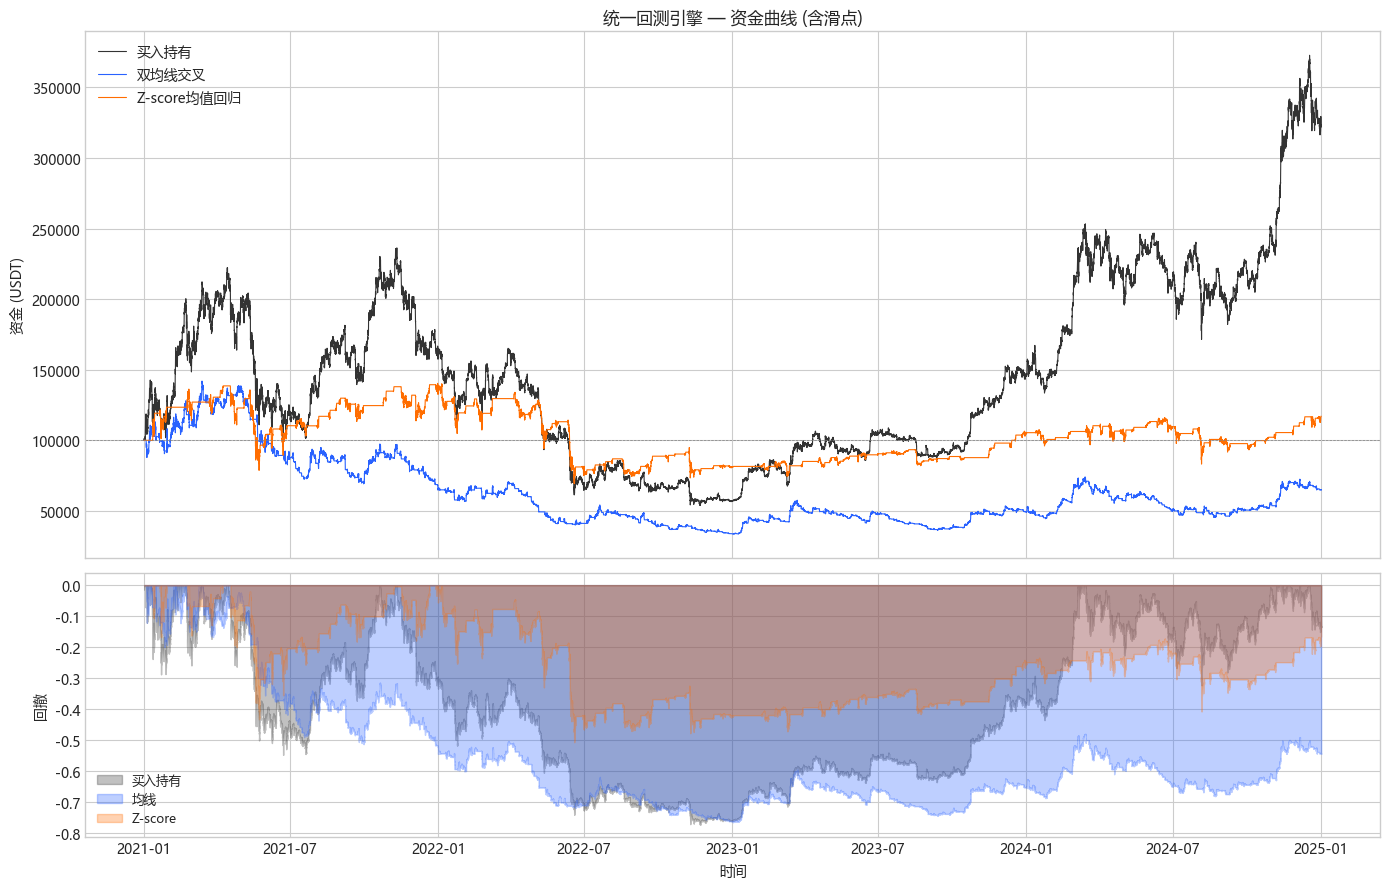

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True,
                          gridspec_kw={'height_ratios': [2, 1]})

# 资金曲线
axes[0].plot(eq_hold.index, eq_hold['capital'], linewidth=0.8, color='#333', label='买入持有')
axes[0].plot(eq_ma.index, eq_ma['capital'], linewidth=0.8, color='#2962FF', label='双均线交叉')
axes[0].plot(eq_zs.index, eq_zs['capital'], linewidth=0.8, color='#FF6D00', label='Z-score均值回归')
axes[0].axhline(100000, color='gray', linestyle='--', linewidth=0.5)
axes[0].set_ylabel('资金 (USDT)')
axes[0].set_title('统一回测引擎 — 资金曲线 (含滑点)')
axes[0].legend()

# 回撤曲线
for eq, color, label in [(eq_hold, '#333', '买入持有'), 
                           (eq_ma, '#2962FF', '均线'), 
                           (eq_zs, '#FF6D00', 'Z-score')]:
    peak = eq['cumulative'].cummax()
    dd = (eq['cumulative'] - peak) / peak
    axes[1].fill_between(eq.index, dd, 0, alpha=0.3, color=color, label=label)

axes[1].set_ylabel('回撤')
axes[1].set_xlabel('时间')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## 小结

**回测引擎功能**
- 逐K线模拟，支持分仓（0~100%仓位）
- 包含手续费（0.1%）和滑点（0.05%）模拟
- 输出资金曲线、回撤曲线、逐笔交易记录

**加入滑点后的影响**
| 策略 | 不含滑点 | 含滑点 | 差异 |
|------|----------|--------|------|
| 买入持有 | +218% | +222% | 几乎无影响（只交易1次） |
| 双均线交叉 | -6.9% | -35.2% | 725次交易，滑点累积严重 |
| Z-score | +35.3% | +17.1% | 286次交易，滑点吃掉一半收益 |

**关键发现**
- 交易频率是隐性成本杀手：均线策略725次交易导致滑点损失近30个百分点
- 更现实的回测（含滑点）进一步验证了买入持有在BTC市场的优势